In [1]:
import pandas as pd

In [2]:
orders_df = pd.read_csv('../data/Orders.csv')
orders_df.head()

,Order ID,Order Date,CustomerName,State,City
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura
1,B-25993,03-02-2018,Madhav,Delhi,Delhi
2,B-25973,24-01-2018,Madan Mohan,Uttar Pradesh,Mathura
3,B-25923,27-12-2018,Gopal,Maharashtra,Mumbai
4,B-25757,21-08-2018,Vishakha,Madhya Pradesh,Indore


In [3]:
details_df = pd.read_csv('../data/Details.csv')
details_df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card


In [4]:
orders_df.columns
orders_df.shape
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order ID      500 non-null    str  
 1   Order Date    500 non-null    str  
 2   CustomerName  500 non-null    str  
 3   State         500 non-null    str  
 4   City          500 non-null    str  
dtypes: str(5)
memory usage: 19.7 KB


In [5]:
details_df.columns
details_df.shape
details_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order ID      1500 non-null   str  
 1   Amount        1500 non-null   int64
 2   Profit        1500 non-null   int64
 3   Quantity      1500 non-null   int64
 4   Category      1500 non-null   str  
 5   Sub-Category  1500 non-null   str  
 6   PaymentMode   1500 non-null   str  
dtypes: int64(3), str(4)
memory usage: 82.2 KB


In [6]:
merged_df = pd.merge(orders_df, details_df, on='Order ID', how = 'inner')
merged_df

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,5729,64,14,Furniture,Chairs,EMI
1,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,671,114,9,Electronics,Phones,Credit Card
2,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,443,11,1,Clothing,Saree,COD
3,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,57,7,2,Clothing,Shirt,UPI
4,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,227,48,5,Clothing,Stole,COD
...,...,...,...,...,...,...,...,...,...,...,...
1495,B-25742,03-08-2018,Ashwin,Goa,Goa,11,-8,2,Clothing,Skirt,UPI
1496,B-26088,26-03-2018,Bhavna,Sikkim,Gangtok,11,5,2,Clothing,Hankerchief,UPI
1497,B-25707,01-07-2018,Shivani,Maharashtra,Mumbai,8,-6,1,Clothing,Stole,COD
1498,B-25758,22-08-2018,Shubham,Himachal Pradesh,Simla,8,-2,1,Clothing,Stole,COD


In [7]:
# Total Sales Revenue
merged_df['Amount'].sum()

np.int64(437771)

In [8]:
# Total Profit
merged_df['Profit'].sum()


np.int64(36963)

In [9]:
# Total Quantity Sold
merged_df['Quantity'].sum()

np.int64(5615)

In [10]:
# Total Number of Orders
merged_df['Order ID'].nunique()

500

In [14]:
# Which category generated highest revenue?
highest_revenue = merged_df.groupby('Category')['Amount'].sum()
highest_revenue.idxmax()

'Electronics'

In [16]:
# Which category generated highest profit?
highest_profit = merged_df.groupby('Category')['Profit'].sum()
highest_profit.idxmax()

'Clothing'

In [20]:
# Which Sub-Category sold the highest Quantity?
highest_quantity = merged_df.groupby('Sub-Category')['Quantity'].sum()
highest_quantity.idxmax()

'Saree'

In [23]:
# Which payment mode is used most?
most_used = merged_df.value_counts('PaymentMode')
most_used.idxmax()

'COD'

In [30]:
# Top 5 Customers by Revenue
top_cust = merged_df.groupby('CustomerName')['Amount'].sum()
top_cust.sort_values(ascending=False).head(5)

CustomerName
Harivansh      9902
Madhav         9365
Madan Mohan    7766
Shiva          6339
Vishakha       6120
Name: Amount, dtype: int64

In [31]:
# Top 5 States by Revenue
top_states = merged_df.groupby('State')['Amount'].sum()
top_states.sort_values(ascending=False).head(5)

State
Maharashtra       102498
Madhya Pradesh     87463
Uttar Pradesh      38362
Delhi              22957
Rajasthan          22334
Name: Amount, dtype: int64

In [32]:
# Which category generated the highest profit in Maharashtra?
filtered_df = merged_df[merged_df['State'] == 'Maharashtra']
res = filtered_df.groupby('Category')['Profit'].sum()
res.idxmax()

'Clothing'

In [35]:
# Which State Generated the Highest Profit?
state_profit = merged_df.groupby('State')['Profit'].sum()
state_profit.idxmax()

'Madhya Pradesh'

In [37]:
# Which customer generated the highest profit?
high_pro = merged_df.groupby('CustomerName')['Profit'].sum()
high_pro.idxmax()

'Madan Mohan'

In [38]:
import matplotlib.pyplot as plt

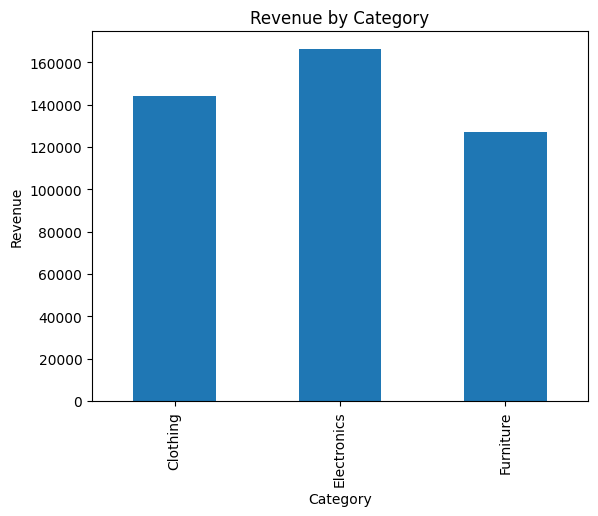

In [39]:
category_revenue = merged_df.groupby('Category')['Amount'].sum()

category_revenue.plot(kind='bar')

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()

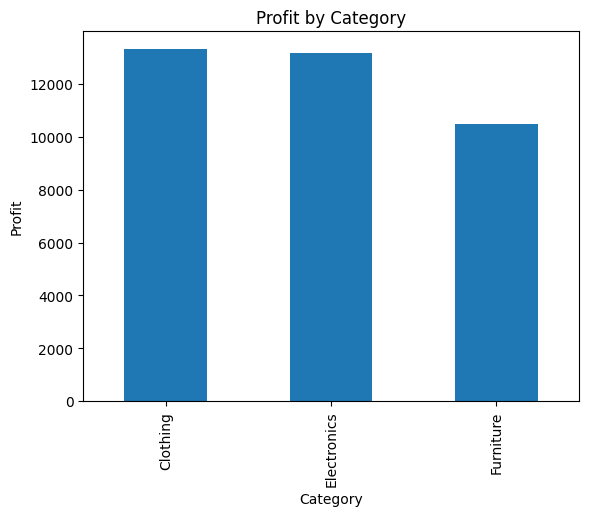

In [40]:
category_profit = merged_df.groupby('Category')['Profit'].sum()

category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.show()

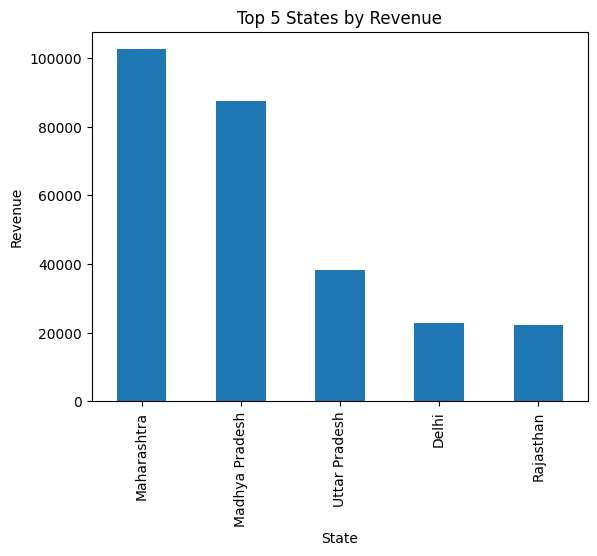

In [41]:
top_states = merged_df.groupby('State')['Amount'].sum()

top_states = top_states.sort_values(ascending=False).head(5)

top_states.plot(kind='bar')

plt.title('Top 5 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

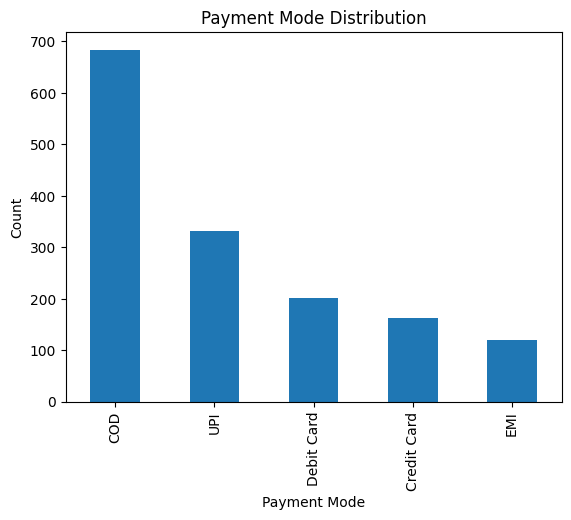

In [42]:
payment_mode = merged_df['PaymentMode'].value_counts()

payment_mode.plot(kind='bar')

plt.title('Payment Mode Distribution')
plt.xlabel('Payment Mode')
plt.ylabel('Count')

plt.show()

# Business Insights

1. Electronics generated the highest revenue.
2. Clothing generated the highest profit.
3. Saree was the highest-selling sub-category by quantity.
4. COD was the most frequently used payment mode.
5. Harivansh generated the highest revenue among customers.
6. Madan Mohan generated the highest profit among customers.
7. Maharashtra generated the highest revenue among states.
8. Madhya Pradesh generated the highest profit among states.
9. Clothing generated the highest profit in Maharashtra.

# Conclusion

This project analyzed e-commerce sales data to identify revenue trends, profit drivers, customer behavior, and payment preferences.

Key findings include:

- Electronics generated the highest revenue.
- Clothing generated the highest profit.
- Saree was the highest-selling sub-category.
- COD was the most commonly used payment method.
- Maharashtra generated the highest revenue.
- Madhya Pradesh generated the highest profit.

This analysis demonstrates the use of Python, Pandas, Data Aggregation, Data Visualization, and Business Intelligence techniques to derive actionable insights from sales data.